# Questo codice allena un mamba (MambaForCausalLM) preso dalla libreria transformes. Il training non è di tipo "classico", ma viene svolto per steps come descritto nel paper di Mamba 1.
## Con questo codice è possibile modificare lo spacing nelle sequenze di associative recall e patchare la funzione [cuda_kernels_forward](https://github.com/huggingface/transformers/blob/main/src/transformers/models/mamba/modeling_mamba.py) (quindi togliere la convoluzionale).
## Per allenare il modello più velocemente bisogna importare le due librerie mamba_ssm e causal_conv1d, siccome colab non ha le wheels di queste due librerie in questa [cartella](https://drive.google.com/drive/folders/1KZjTurigpMq8XVWkVL58vAfz-VJgS8VH?usp=sharing).
### Nota: serve la GPU e va messo il path giusto per le wheels delle librerie.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu126 -q
import torch

# Bisogna installare la versione corretta di transformers che è la 4.57.6
!pip uninstall transformers -y
!pip -q install transformers==4.57.6
import transformers

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version: {torch.version.cuda}")

#Con questi comandi puoi importare mamba_ssm e causal_conv1d, ma devi avere i files.whl sul drive nella cartella giusta
!pip install -q /content/drive/MyDrive/mamba/mamba_librerie_python/mamba_ssm-2.2.6.post3-cp312-cp312-linux_x86_64.whl
!pip install -q /content/drive/MyDrive/mamba/mamba_librerie_python/causal_conv1d-1.5.3.post1-cp312-cp312-linux_x86_64.whl

!git clone https://github.com/WillyPuri/my_mamba.git

from my_mamba.symple_induction_head_dataset import TokenInductionHeadDataset, Make_Tokenizer, From_Seq_To_Numb, print_sequence
from my_mamba.patch_functions import patched_no_conv1d_cuda

from transformers import MambaConfig, MambaForCausalLM, AutoTokenizer
from transformers.models.mamba.modeling_mamba import MambaMixer, MambaCache

import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

from torch.utils.data import TensorDataset, DataLoader

Mounted at /content/drive
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 141.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 211.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 172.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 54.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 137.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 115.7 MB/s eta 0:

In [2]:
patch_conv1d = False                          # True indica che si toglie la conv1d, False indica che questa rimane
vocab_size = 16
seq_len = 256
batch_size = 8
special_token = "A"
num_special_tokens = 1
spacing = 1
vali_dataset_size = 10000
sep_vocab = False

dataloader = dict()

dataset_vali = TokenInductionHeadDataset(seq_len=seq_len, dataset_size=vali_dataset_size, vocab_size= vocab_size, special_token=special_token, num_special_tokens = num_special_tokens, spacing = spacing, sep_vocab=sep_vocab)
tokenizer = dataset_vali.tokenizer
data_vali, targets_vali = From_Seq_To_Numb(tokenizer,dataset_vali)
dataset_validation = TensorDataset(data_vali,targets_vali)
dataloader['vali'] = DataLoader(dataset_validation, batch_size=batch_size)       # Creo un dataloader per il validation perchè deve essere sempre lo stesso

dataset_test = TokenInductionHeadDataset(seq_len=seq_len, dataset_size=vali_dataset_size, vocab_size= vocab_size, special_token=special_token, num_special_tokens = num_special_tokens, spacing = spacing, sep_vocab=sep_vocab)
data_test, targets_test = From_Seq_To_Numb(tokenizer,dataset_test)
dataset_test = TensorDataset(data_test,targets_test)
dataloader['test'] = DataLoader(dataset_test, batch_size=batch_size)       # Creo un dataloader per il test

for j, (seq_print, targets_print) in enumerate(dataset_vali):
  if j < 5:
    print_sequence(seq_print, seq_print[-1],spacing)

E E E D P J E F H D N L L B E C H O E D B C F M D E F O G M K C H K D B B J J G L C F L C K B N L M C D H G C K H C H B B N D P I I I I G A J H O L K G H N K D N M L M D B K L J J L L K C B M D H I O D H J B M L D G E J F H G D M O L H P N I J D K D P L P N P L G C M N F E O O C P N E M B B H G N G O G E N I L D P I E G D N H C O B O I C P K N I N H O G K B O D E E O C L I D G H D B N E B N F E P C J L N D D P O D M J K J H O E B N K M P J B H K N N B K M D F K M B G B H H L M L G D B F E G K K H O I H H A
Target: J
O I M J E N D E I D K M M K H K L B M F J F C M I O P O E G C C O P G H M A N H O B I E K N J G D F M I F M P G F C M D H I P M M F H E F L D K D M E N M K P M C F D N C I C C H I G K L K H C E K K K F L N E F H P D P C I M M P J M O L P E C G K H C G D N J C N P H F H P E N J I J E C C O N C D O G C E B J C K P F N C N L P N P K C P P E I G I J I C B P M O K D L E C B B N C D I L N L C D K G M J H C L D P O K I J N L H J M I N I H K C H M O J F M F G N N K F N J E O G M I 

In [3]:
# controlliamo se la GPU è disponibile e nel caso quale tipo di GPU
if torch.cuda.is_available():
  print('Numero di GPU disponibili: ',torch.cuda.device_count())
  for i in range(0,torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

# se la GPU è disponibile setto device='cuda', altrimenti 'cpu
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Computation device: {device}\n")

Numero di GPU disponibili:  1
Tesla T4
Computation device: cuda



In [4]:
custom_vocab_size = (
    dataset_vali.vocab_size + num_special_tokens
    if sep_vocab is not None and sep_vocab == True
    else dataset_vali.vocab_size
)

print('vocab_size:',vocab_size)

config = MambaConfig(
        vocab_size=custom_vocab_size,
        hidden_size=64,
        state_size=16,
        num_hidden_layers=1,
        layer_norm_epsilon=1e-5,
        pad_token_id=0,
        bos_token_id=0,
        eos_token_id=0,
        expand=2,
        conv_kernel=4,
        use_bias=False,
        use_conv_bias=True,
        hidden_act="silu",
        initializer_range=0.1,
        residual_in_fp32=True,
        time_step_rank="auto",
        time_step_scale=1.0,
        time_step_min=0.001,
        time_step_max=0.1,
        time_step_init_scheme="random",
        time_step_floor=1e-4,
        rescale_prenorm_residual=False,
        use_cache=True,
        use_mambapy=False,
)

vocab_size: 16


In [5]:
if patch_conv1d:
  MambaMixer.cuda_kernels_forward = patched_no_conv1d_cuda                      # Modifico il forward per togliere la conv1d dal modello

model = MambaForCausalLM(config).to(device)

if patch_conv1d:
  for layer in model.backbone.layers:
    del layer.mixer.conv1d

print(model)
print(f"Parametri del modello: {sum(p.numel() for p in model.parameters()):,}")

MambaForCausalLM(
  (backbone): MambaModel(
    (embeddings): Embedding(16, 64)
    (layers): ModuleList(
      (0): MambaBlock(
        (norm): MambaRMSNorm(64, eps=1e-05)
        (mixer): MambaMixer(
          (conv1d): Conv1d(128, 128, kernel_size=(4,), stride=(1,), padding=(3,), groups=128)
          (act): SiLUActivation()
          (in_proj): Linear(in_features=64, out_features=256, bias=False)
          (x_proj): Linear(in_features=128, out_features=36, bias=False)
          (dt_proj): Linear(in_features=4, out_features=128, bias=True)
          (out_proj): Linear(in_features=128, out_features=64, bias=False)
        )
      )
    )
    (norm_f): MambaRMSNorm(64, eps=1e-05)
  )
  (lm_head): Linear(in_features=64, out_features=16, bias=False)
)
Parametri del modello: 33,792


In [6]:
import torch
from torch import nn
from torch.optim import AdamW
from torch import optim
from torch.optim.lr_scheduler import StepLR

num_epochs = 25
num_steps = 8192
LR_ST = 5e-3
WEIGHT_DECAY = 0

device = 'cuda' if torch.cuda.is_available() else 'cpu'

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr=LR_ST,
    weight_decay=WEIGHT_DECAY,  # Regolarizzazione L2
)

### Da qui parte il traning loop

In [7]:
t_loss = []
v_loss = []
t_acc = []
v_acc = []
predictions_list = []

best_loss = float('inf')
for epoch in range(num_epochs):
    # ========================================
    # TRAINING
    # ========================================
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for step in range(num_steps):
        # creo un batch di 8 sequenze
        dataset = TokenInductionHeadDataset(seq_len=seq_len, dataset_size=batch_size, vocab_size= vocab_size, special_token=special_token, num_special_tokens = num_special_tokens,spacing=spacing, sep_vocab=sep_vocab)
        input_ids, target_ids = From_Seq_To_Numb(tokenizer,dataset)


        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        target_ids = target_ids.squeeze(-1) # Fix: Reshape target_ids to be 1D

        # Forward pass
        outputs = model(input_ids)
        logits = outputs.logits
        last_logits = logits[:, -1, :]

        # Loss
        loss = criterion(last_logits, target_ids)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistiche
        total_loss += loss.item()
        predictions = torch.argmax(last_logits, dim=-1)
        correct += (predictions == target_ids).sum().item()
        total += batch_size

    avg_train_loss = total_loss / num_steps
    train_accuracy = correct / total
    t_loss.append(avg_train_loss)
    t_acc.append(train_accuracy)

    # ========================================
    # VALIDATION
    # ========================================
    model.eval()
    vali_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for input_ids, target_ids in dataloader['vali']:
            input_ids = input_ids.to(device)
            target_ids = target_ids.to(device)
            target_ids = target_ids.squeeze(-1) # Fix: Reshape target_ids to be 1D

            outputs = model(input_ids)
            logits = outputs.logits
            last_logits = logits[:, -1, :]

            vloss = criterion(last_logits, target_ids)
            vali_loss += vloss.item()

            predictions = torch.argmax(last_logits, dim=-1)
            predictions_list.append(predictions.cpu().numpy())
            correct += (predictions == target_ids).sum().item()
            total += batch_size

    avg_vali_loss = vali_loss / len(dataloader['vali'])
    vali_accuracy = correct / total
    v_loss.append(avg_vali_loss)
    v_acc.append(vali_accuracy)

    lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
    print(f"  Valid Loss: {avg_vali_loss:.4f}, Valid Acc: {vali_accuracy:.4f}")
    print(f"  LR: {lr:.6f}")

    if avg_vali_loss<=best_loss:
      best_loss = avg_vali_loss
      best_model_filename = (f"layers{config.num_hidden_layers}_patchconv{patch_conv1d}_spacing{spacing}_spectoks{num_special_tokens}_vocabsize{vocab_size}.pt")
      torch.save({
        "model_state_dict": model.state_dict(),
        "config": config.to_dict(),}, best_model_filename)

      print(f"Model saved at epoch {epoch+1}")

Epoch 1/25
  Train Loss: 0.3700, Train Acc: 0.8771
  Valid Loss: 0.0082, Valid Acc: 0.9978
  LR: 0.005000
Model saved at epoch 1
Epoch 2/25
  Train Loss: 0.0060, Train Acc: 0.9982
  Valid Loss: 0.0002, Valid Acc: 1.0000
  LR: 0.005000
Model saved at epoch 2
Epoch 3/25
  Train Loss: 0.0030, Train Acc: 0.9996
  Valid Loss: 0.0000, Valid Acc: 1.0000
  LR: 0.005000
Model saved at epoch 3
Epoch 4/25
  Train Loss: 0.0022, Train Acc: 0.9996
  Valid Loss: 0.0000, Valid Acc: 1.0000
  LR: 0.005000
Epoch 5/25
  Train Loss: 0.0000, Train Acc: 1.0000
  Valid Loss: 0.0000, Valid Acc: 1.0000
  LR: 0.005000
Model saved at epoch 5
Epoch 6/25
  Train Loss: 0.0037, Train Acc: 0.9994
  Valid Loss: 0.0000, Valid Acc: 1.0000
  LR: 0.005000
Epoch 7/25
  Train Loss: 0.0000, Train Acc: 1.0000
  Valid Loss: 0.0000, Valid Acc: 1.0000
  LR: 0.005000
Model saved at epoch 7
Epoch 8/25
  Train Loss: 0.0000, Train Acc: 1.0000
  Valid Loss: 0.0000, Valid Acc: 1.0000
  LR: 0.005000
Model saved at epoch 8
Epoch 9/25
  T

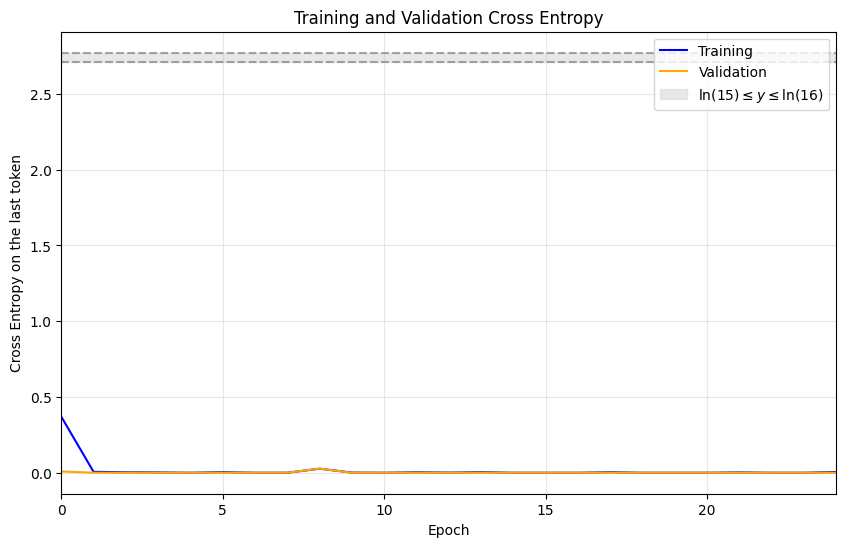

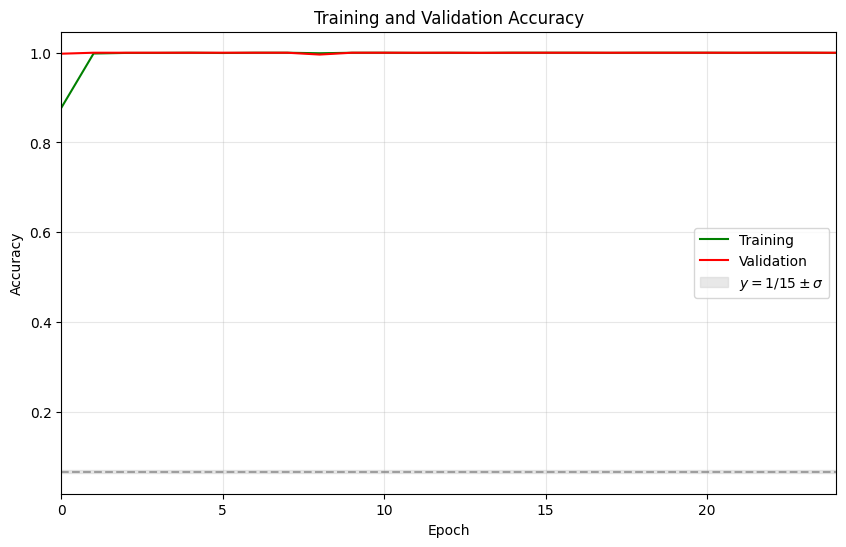

In [8]:
# ========================================
# VISUALIZZAZIONE
# ========================================

# Loss plot
plt.figure(figsize=(10, 6))
plt.plot(t_loss, label='Training', color='blue')
plt.plot(v_loss, label='Validation', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy on the last token')
plt.title('Training and Validation Cross Entropy')
#plt.axhline(y=np.log(15.25), color='purple', linestyle='--', alpha=0.7, label=r"$y=\ln(15.25)$")
plt.axhspan(np.log(15), np.log(16), color='lightgray', alpha=0.5, label=r'$\ln(15) \leq y \leq \ln(16)$')
plt.axhline(y=np.log(15), color='gray', linestyle='--', alpha=0.7)
plt.axhline(y=np.log(16), color='gray', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.xlim(0, len(t_loss)-1)
plt.grid(True, alpha=0.3)
plt.show()

# Accuracy plot
plt.figure(figsize=(10, 6))
plt.plot(t_acc, label='Training', color='green')
plt.plot(v_acc, label='Validation', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.axhline(y=1/15, color='gray', linestyle='--', alpha=0.7)
plt.axhspan(1/15-0.0025, 1/15+0.0025, color='lightgray', alpha=0.5, label=r"$y=1/15 \pm \sigma$")
#plt.axhline(y=1/14, color='gray', linestyle='--', alpha=0.7)
#plt.axhline(y=1/16, color='gray', linestyle='--', alpha=0.7)
plt.legend()
plt.xlim(0, len(t_loss)-1)
plt.grid(True, alpha=0.3)
plt.show()

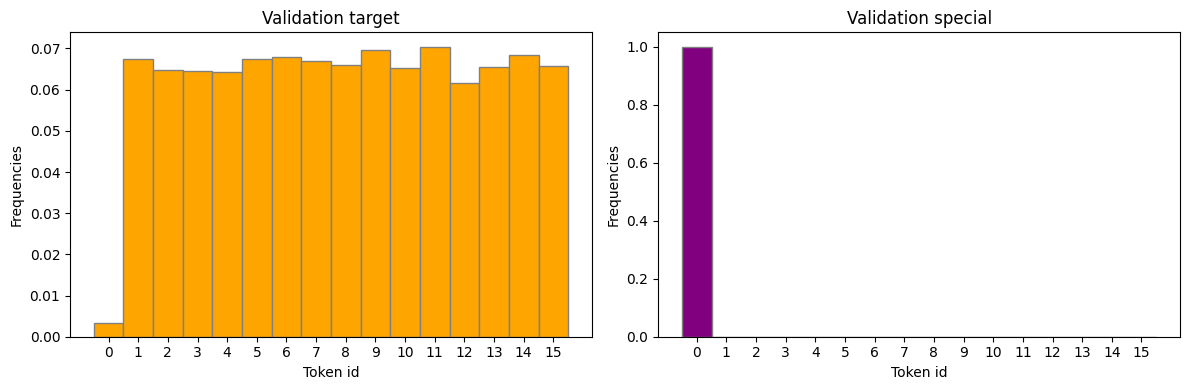

In [9]:
target_vali_occ = targets_vali.view(-1).numpy()
special_vali_occ = data_vali[:, -1].view(-1).numpy()

bin_edges = np.linspace(0, vocab_size, vocab_size + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    target_vali_occ,
    bins=bin_edges,
    density=True,
    color='orange',
    edgecolor='gray'
)
axes[0].set_title('Validation target')

axes[1].hist(
    special_vali_occ,
    bins=bin_edges,
    density=True,
    color='purple',
    edgecolor='gray'
)
axes[1].set_title('Validation special')

step = max(1, vocab_size // 20)
for ax in axes:
    ax.set_xticks(bin_centers[::step])
    ax.set_xticklabels(bin_centers[::step].astype(int))
    ax.set_xlabel('Token id')
    ax.set_ylabel('Frequencies')

plt.tight_layout()
plt.show()

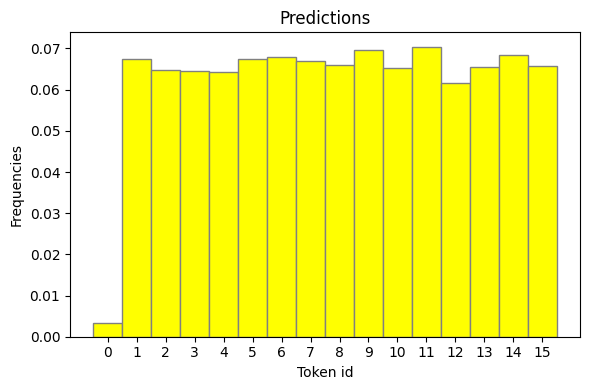

In [10]:
loaded_checkpoint = torch.load(best_model_filename, map_location=device)
model.load_state_dict(loaded_checkpoint["model_state_dict"])
model.eval()
predictions_list = []
with torch.no_grad():
    for input_ids, target_ids in dataloader['vali']:
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        target_ids = target_ids.squeeze(-1) # Fix: Reshape target_ids to be 1D

        outputs = model(input_ids)
        logits = outputs.logits
        last_logits = logits[:, -1, :]

        predictions = torch.argmax(last_logits, dim=-1)
        predictions_list.append(predictions.cpu().numpy())

prediction_occ = np.concatenate(predictions_list)

bin_edges = np.linspace(0, vocab_size, vocab_size + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, axes = plt.subplots(1, 1, figsize=(6, 4))

axes.hist(
    prediction_occ,
    bins=bin_edges,
    density=True,
    color='yellow',
    edgecolor='gray'
)
axes.set_title('Predictions')

step = max(1, vocab_size // 20)
# Changed 'for ax in axes:' to directly use 'axes'
axes.set_xticks(bin_centers[::step])
axes.set_xticklabels(bin_centers[::step].astype(int))
axes.set_xlabel('Token id')
axes.set_ylabel('Frequencies')

plt.tight_layout()
plt.show()

In [11]:
# ========================================
# TEST EVALUATION
# ========================================
print("\n" + "="*50)
print("EVALUATING BEST MODEL ON TEST SET")
print("="*50)

loaded_checkpoint = torch.load(best_model_filename, map_location=device)
model.load_state_dict(loaded_checkpoint["model_state_dict"])
model.eval()
test_loss = 0.0
correct = 0
total = 0

# Esempio di predizioni
print("\nEsempi di predizioni:")
with torch.no_grad():
    for idx, (input_ids, target_ids) in enumerate(dataloader['test']):
        input_ids = input_ids.to(device)
        target_ids = target_ids.to(device)
        target_ids = target_ids.squeeze(-1) # Fix: Reshape target_ids to be 1D

        outputs = model(input_ids)
        logits = outputs.logits
        last_logits = logits[:, -1, :]

        loss = criterion(last_logits, target_ids)
        test_loss += loss.item()

        predictions = torch.argmax(last_logits, dim=-1)
        correct += (predictions == target_ids).sum().item()
        total += batch_size

        # Stampa primi 3 esempi
        if idx == 0:
            for i in range(8):
              predictions_token = tokenizer.id_to_token(predictions[i].item())
              seq_tokens = [tokenizer.id_to_token(token_id.item()) for token_id in input_ids[i]]
              print_sequence(seq_tokens, seq_tokens[-1], spacing, predictions_token)

test_accuracy = correct / total
print(f"\nTEST RESULTS:")
print(f"  Learning Rate: {LR_ST}")
print(f"  Loss: {test_loss/len(dataloader['test']):.4f}")
print(f"  Accuracy: {test_accuracy:.4f}")
print("="*50)


EVALUATING BEST MODEL ON TEST SET

Esempi di predizioni:
H E N F E O L M O H C I C E B D B H J N O K G M D B I B F C P I F L I E B I L H P H D I H G J F H P N L B G H J N O K M N P K C D O F E I K K N D D N G K D O G K H C J O P L D D D C M J J E D P K E N B M H E F E I J M G I P C O F G O L G P K E G P J D D O E B F N J B B L O I L N E C H E D P H H N C B D A P J C F D J F J E I J F K I G K F J K H P P N I H N P G B B P C B M M J H H H G G O B K C D G F H G E C J L I F P F B M L J G H D E F I G H G M N J E H C F B F F B E K P F F E D F E N J B I P N E I K C D A
Target: P  Prediction: P  Result: True
N O D L C A L K F F O G I I O N M O L E O G F N H J B N I C L F D O C E C M N H C F O I M O H L M B O E O N P K C I E I M I O F B H M O P L H K M H M D J C E B J O P K N N I P I C P C E M F O I D J G D L N I D G L E E N K H K L J G P D E I C C P B F H D K N K H M F F L B B P M L F K L L D F B O E P P J D D I I L H K B O F E D N K M J I O J O E C F O G M F B D J K O N D K C G H E G D M L E

In [12]:
from IPython.display import Audio, display

# Parametri del suono
frequency = 1000
duration = 1
sampling_rate = 44100

t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
wave = 0.5 * np.sin(2 * np.pi * frequency * t)

display(Audio(wave, rate=sampling_rate, autoplay=True))